## Step 3.2 : Indice de marchabilité pondéré selon le contexte urbain / non urbain

Ce notebook recalcule l'indice de marchabilité sur le carroyage 200 m avec **deux jeux de poids** :
- les carreaux `urbain = 1` reçoivent les poids du fichier **urbain** (ex. `urbain_fonctionnel`)
- les carreaux `urbain = 0` reçoivent les poids du fichier **non urbain** (ex. `rural_loisir`)

**Entrées**
- `step3_aggregated_index_carreau200.parquet` : attributs déjà normalisés [0, 1] et inversés (défavorable → 1 - x), agrégés par carreau
- `AGGLO_CARREAU_200_urbain.gpkg` : carroyage avec la variable `urbain` (notebook précédent)
- deux fichiers `attributs_info_{network}_{type}.xlsx` (même format que pour le step 3)

**Sortie** : un GeoPackage = le parquet + `urbain` + `walk_index_geo` (l'indice pondéré géographiquement)

**Pourquoi on peut repondérer après l'agrégation.** L'indice est une somme pondérée des attributs, et l'agrégation au carreau est une moyenne. Les deux opérations sont linéaires : on peut donc les faire dans n'importe quel ordre. Repondérer les attributs agrégés donne le même classement des carreaux que repondérer chaque tronçon puis agréger. Le clipping et la normalisation ont déjà été faits au niveau des tronçons.

In [1]:
import os
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

**Paramètres**

In [2]:
operation_crs = "EPSG:2056"
target_crs = "EPSG:4326"   # CRS de sortie, comme les autres sorties du step 3

territory = "GG"   # GG ou GE
network = "walk"   # walk ou bike

# Jeux de poids : un par contexte
type_urbain = "unweighted"
type_non_urbain = "rural_loisir"

input_file_path = "../../Data/input"
output_base = f"../../Data/output/{network}/{territory}"

# Parquet agrégé au carreau 200 m (adapter le dossier si besoin)
aggregated_path = f"{output_base}/step-3_unweighted/step3_aggregated_index_carreau200.parquet"
# Carroyage avec la variable urbain (produit par le notebook d'agrégation de la tache urbaine)
carreaux_urbain_path = f"{output_base}/geographic_weighting/carreau_200_urbain.gpkg"

weights_urbain_path = f"{input_file_path}/attributs/attributs_info_{network}_{type_urbain}.xlsx"
weights_non_urbain_path = f"{input_file_path}/attributs/attributs_info_{network}_{type_non_urbain}.xlsx"

save_path = f"{output_base}/step-3_geo_weighted"
output_gpkg = f"{save_path}/step3_index_carreau200_geo_weighted.gpkg"

include = f"include_in_index_{territory}"
index_col = f"{network}_index"
geo_index_col = f"{network}_index_geo"

KEY = "GRID_ID"  # identifiant commun parquet / carroyage

# Mise à l'échelle finale de l'indice pondéré :
#   False -> moyenne pondérée (Σ w·x / Σ w). Reste dans [0, 1] et les deux régimes sont comparables
#            même si la somme des poids diffère.
#   True  -> en plus, min-max sur l'ensemble des carreaux ([0, 1] étiré, comme walk_index).
MINMAX_FINAL = False

# Routes départementales hors agglo (step 3) : les tronçons masqués y avaient un indice NaN,
# mais leurs attributs sont quand même dans les moyennes par carreau.
# On met l'indice à NaN pour les carreaux dont la part masquée est >= au seuil (1.0 = entièrement masqués).
MASK_RD_HORS_AGGLO = True
RD_MASK_THRESHOLD = 1.0

## 1. Chargement des données

In [3]:
agg = gpd.read_parquet(aggregated_path)
carreaux_urbain = gpd.read_file(carreaux_urbain_path, columns=[KEY, "urbain"], ignore_geometry=True)

print("Parquet agrégé :", agg.shape, agg.crs)
print("Carroyage urbain :", carreaux_urbain.shape)

Parquet agrégé : (40946, 40) {"$schema": "https://proj.org/schemas/v0.7/projjson.schema.json", "type": "GeographicCRS", "name": "WGS 84", "datum_ensemble": {"name": "World Geodetic System 1984 ensemble", "members": [{"name": "World Geodetic System 1984 (Transit)"}, {"name": "World Geodetic System 1984 (G730)"}, {"name": "World Geodetic System 1984 (G873)"}, {"name": "World Geodetic System 1984 (G1150)"}, {"name": "World Geodetic System 1984 (G1674)"}, {"name": "World Geodetic System 1984 (G1762)"}, {"name": "World Geodetic System 1984 (G2139)"}, {"name": "World Geodetic System 1984 (G2296)"}], "ellipsoid": {"name": "WGS 84", "semi_major_axis": 6378137, "inverse_flattening": 298.257223563}, "accuracy": "2.0", "id": {"authority": "EPSG", "code": 6326}}, "coordinate_system": {"subtype": "ellipsoidal", "axis": [{"name": "Geodetic latitude", "abbreviation": "Lat", "direction": "north", "unit": "degree"}, {"name": "Geodetic longitude", "abbreviation": "Lon", "direction": "east", "unit": "deg

## 2. Chargement des poids (urbain / non urbain)

Même logique qu'au step 3 :
- on ne garde que les attributs avec `include_in_index_{territory} = True`
- chaque poids doit être entre 0 et 1

Un attribut exclu d'un des deux fichiers compte avec un poids 0 pour ce régime.

In [4]:
def load_weights(path, label):
    info = pd.read_excel(path, sheet_name="attributs_info")
    include_mask = info[include].astype(str).str.strip().str.lower().eq("true")
    info = info.loc[include_mask].copy()

    weights = {}
    for _, row in info.iterrows():
        attr, w = row["attribute"], row["initial_weight"]
        if pd.isnull(w):
            raise ValueError(f"[{label}] poids manquant pour '{attr}'")
        if not (0 <= w <= 1):
            raise ValueError(f"[{label}] poids de '{attr}' = {w}, doit être entre 0 et 1")
        weights[attr] = float(w)

    if not weights:
        raise ValueError(f"[{label}] aucun attribut inclus ({include})")
    return pd.Series(weights, name=label)

w_urbain = load_weights(weights_urbain_path, "urbain")
w_non_urbain = load_weights(weights_non_urbain_path, "non_urbain")

# Table des poids alignée sur l'union des attributs (0 si absent d'un régime)
weights = pd.concat([w_urbain, w_non_urbain], axis=1).fillna(0.0)
attributes = weights.index.tolist()

missing = [a for a in attributes if a not in agg.columns]
if missing:
    raise KeyError(f"Attributs absents du parquet agrégé : {missing}")

print(f"{len(attributes)} attributs")
print("Somme des poids :", weights.sum().round(3).to_dict())
weights

20 attributs
Somme des poids : {'urbain': 2.4, 'non_urbain': 2.5}


,urbain,non_urbain
lac_cours_deau,0.12,0.50
fontaine,0.12,0.00
espaces_ouverts,0.12,0.00
rez_actif,0.12,0.00
tp,0.12,0.25
amenite,0.12,0.00
temperature,0.12,0.50
conflit_md,0.12,0.00
canopee,0.12,0.50
banc,0.12,0.25


## 3. Ajout de la variable `urbain` aux carreaux

In [5]:
n_before = len(agg)
gdf = agg.merge(carreaux_urbain, on=KEY, how="left", validate="one_to_one")
assert len(gdf) == n_before

n_missing = gdf["urbain"].isna().sum()
if n_missing:
    print(f"⚠️ {n_missing} carreaux sans correspondance dans le carroyage urbain -> traités comme non urbains")
gdf["urbain"] = gdf["urbain"].fillna(0).astype("int8")

print(gdf["urbain"].value_counts().rename({1: "urbain", 0: "non urbain"}))

urbain
non urbain    22570
urbain        18376
Name: count, dtype: int64


## 4. Calcul de l'indice pondéré géographiquement

Pour chaque carreau, on prend le jeu de poids de son régime `w_r` (r = urbain ou non urbain) :

$$ I_{geo} = \frac{\sum_i w_{r,i}\, x_i}{\sum_i w_{r,i}} $$

Les attributs `x_i` sont déjà dans [0, 1], avec 1 = favorable.

In [6]:
X = gdf[attributes].to_numpy(dtype=float)

nan_counts = gdf[attributes].isna().sum()
if nan_counts.any():
    print("⚠️ NaN dans les attributs (le carreau aura un indice NaN) :")
    print(nan_counts[nan_counts > 0])

W = np.where(
    gdf["urbain"].to_numpy()[:, None] == 1,
    weights["urbain"].to_numpy()[None, :],
    weights["non_urbain"].to_numpy()[None, :],
)

gdf[geo_index_col] = (X * W).sum(axis=1) / W.sum(axis=1)

if MASK_RD_HORS_AGGLO and "rd_hors_agglo_masked" in gdf.columns:
    rd_mask = gdf["rd_hors_agglo_masked"] >= RD_MASK_THRESHOLD - 1e-9
    gdf.loc[rd_mask, geo_index_col] = np.nan
    print(f"Carreaux masqués (RD hors agglo) : {rd_mask.sum()}")

if MINMAX_FINAL:
    v = gdf[geo_index_col]
    gdf[geo_index_col] = (v - v.min()) / (v.max() - v.min())

gdf[geo_index_col] = gdf[geo_index_col].round(4)

print(gdf.groupby("urbain")[geo_index_col].describe().rename(index={1: "urbain", 0: "non urbain"}))

              count      mean       std     min       25%     50%     75%  \
urbain                                                                      
non urbain  22570.0  0.230264  0.119387  0.0033  0.120625  0.2655  0.3237   
urbain      18376.0  0.218613  0.049949  0.0891  0.178400  0.2116  0.2525   

              max  
urbain             
non urbain  0.569  
urbain      0.471  


## 5. Contrôles

In [8]:
assert gdf[KEY].is_unique
assert gdf[geo_index_col].dropna().between(0, 1).all()
print("NaN dans l'indice :", gdf[geo_index_col].isna().sum())

if index_col in gdf.columns:
    # Avec les mêmes poids qu'au step 3, la corrélation doit être ~1 (hors carreaux touchés par le masque RD)
    if "rd_hors_agglo_masked" in gdf.columns:
        not_masked = gdf["rd_hors_agglo_masked"].fillna(0) == 0
    else:
        not_masked = pd.Series(True, index=gdf.index)
    comp = gdf[not_masked].groupby("urbain")[[index_col, geo_index_col]].corr().xs(index_col, level=1)[geo_index_col]
    print(f"Corrélation {index_col} vs {geo_index_col} par régime :")
    print(comp.rename(index={1: "urbain", 0: "non urbain"}).round(3))

NaN dans l'indice : 0
Corrélation walk_index vs walk_index_geo par régime :
urbain
non urbain    0.750
urbain        0.987
Name: walk_index_geo, dtype: float64


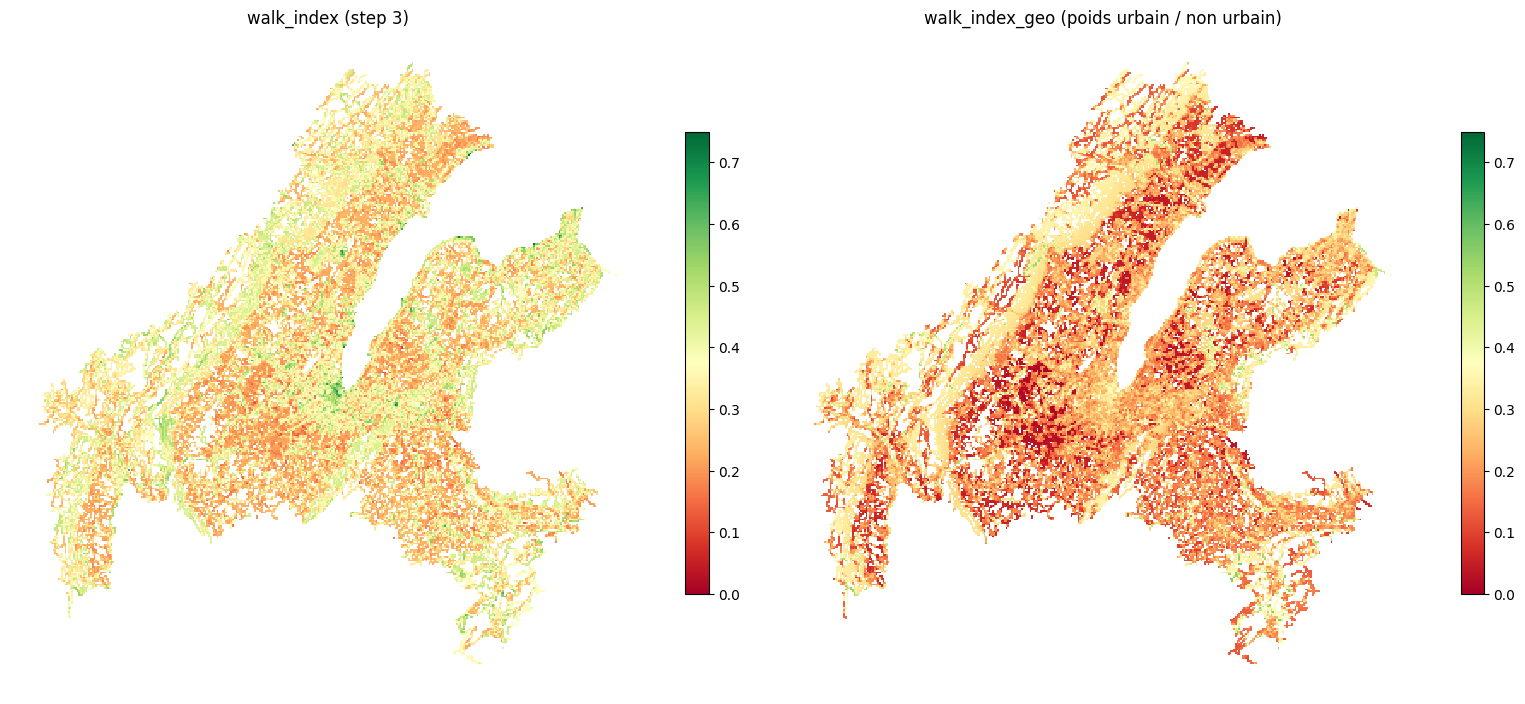

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
plot_gdf = gdf.to_crs(operation_crs)

for ax, col, title in [
    (axes[0], index_col, f"{index_col} (step 3)"),
    (axes[1], geo_index_col, f"{geo_index_col} (poids urbain / non urbain)"),
]:
    plot_gdf.plot(column=col, cmap="RdYlGn", vmin=0, vmax=plot_gdf[[index_col, geo_index_col]].max().max(),
                  linewidth=0, legend=True, legend_kwds={"shrink": 0.6}, ax=ax)
    ax.set_title(title)
    ax.set_axis_off()
plt.tight_layout()

## 6. Export GeoPackage

In [10]:
os.makedirs(save_path, exist_ok=True)
gdf.to_crs(target_crs).to_file(output_gpkg, layer="carreau200_geo_weighted", driver="GPKG")
gdf.to_crs(target_crs).to_parquet(f'{save_path}/carreau200_geo_weighted.parquet')

print("Écrit :", os.path.abspath(output_gpkg))

Écrit : /Users/maximiliantrique/Documents/GitHub/projet-index-walk-bike-ge-gg/Data/output/walk/GG/step-3_geo_weighted/step3_index_carreau200_geo_weighted.gpkg


## 7. Ratio indice pondéré géographiquement / indice non pondéré

`ratio = walk_index_geo / indice non pondéré`, carreau par carreau :
- **> 1 (bleu)** : les poids du régime (urbain ou non urbain) **augmentent** le score du carreau
- **< 1 (rouge)** : ils le **diminuent**
- **= 1 (gris)** : pas d'effet

**Indice de référence.** Par défaut, la référence non pondérée est recalculée ici : moyenne simple des mêmes attributs, sur la même échelle que `walk_index_geo`. La colonne `walk_index_unweighted` du parquet a été min-maxée au niveau des tronçons : le ratio avec elle mélangerait l'effet des poids et un changement d'échelle. Pour l'utiliser quand même : `REF_MODE = "parquet"`.

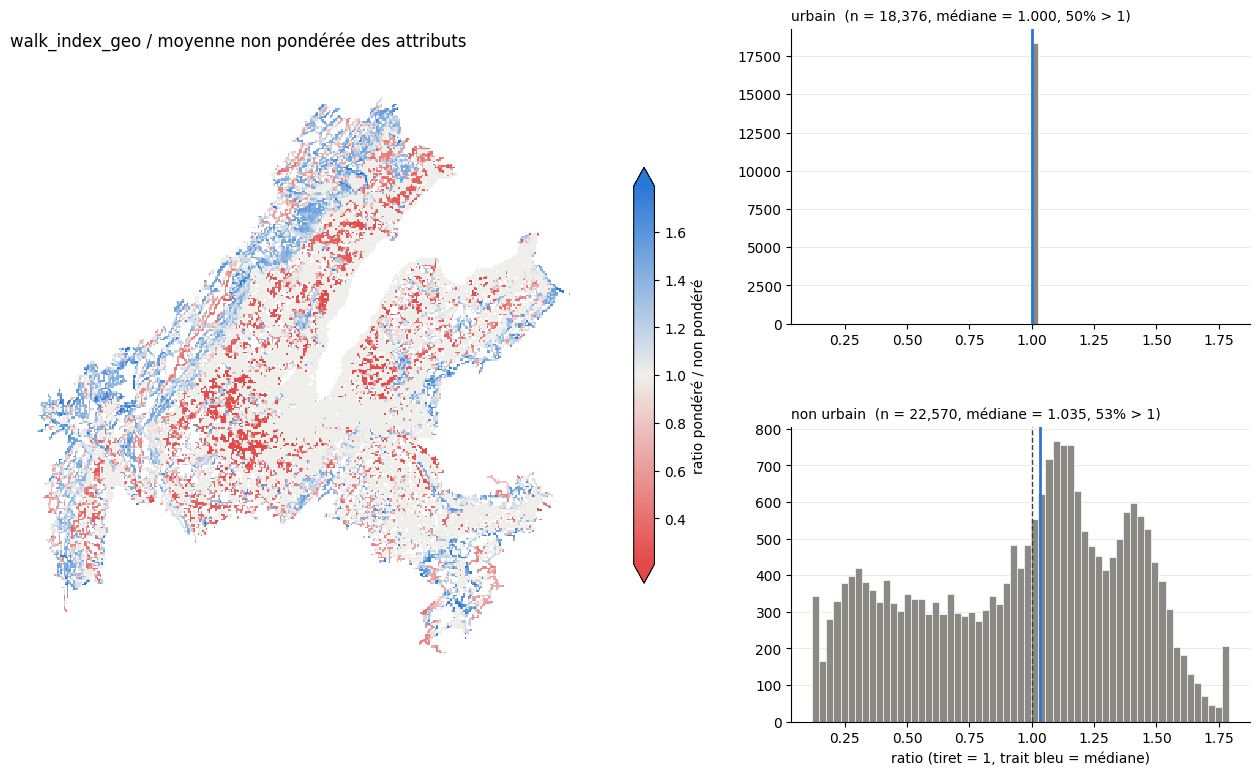

              count   mean    std    min    25%    50%    75%   max
urbain                                                             
non urbain  22570.0  0.953  0.426  0.019  0.594  1.035  1.288  2.32
urbain      18376.0  1.000  0.000  1.000  1.000  1.000  1.000  1.00


In [11]:
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm

REF_MODE = "recompute"   # "recompute" (moyenne simple des attributs) ou "parquet" (colonne walk_index_unweighted)

if REF_MODE == "recompute":
    ref = gdf[attributes].mean(axis=1)
    ref_label = "moyenne non pondérée des attributs"
else:
    ref = gdf[f"{network}_index_unweighted"]
    ref_label = f"{network}_index_unweighted (parquet)"

ratio = gdf[geo_index_col] / ref.where(ref > 0)   # NaN si la référence vaut 0 ou NaN

# Échelle divergente centrée sur 1, bornes symétriques (P2-P98) pour que les extrêmes n'écrasent pas la carte
d = max(abs(ratio.quantile(0.02) - 1), abs(ratio.quantile(0.98) - 1))
norm = TwoSlopeNorm(vmin=1 - d, vcenter=1, vmax=1 + d)
cmap = LinearSegmentedColormap.from_list("div_red_gray_blue", ["#e34948", "#f0efec", "#2a78d6"])

fig = plt.figure(figsize=(16, 9))
gs = fig.add_gridspec(2, 2, width_ratios=[1.6, 1], hspace=0.35, wspace=0.08)

# Carte
ax_map = fig.add_subplot(gs[:, 0])
plot_gdf = gdf.assign(ratio=ratio).to_crs(operation_crs)
plot_gdf.plot(column="ratio", cmap=cmap, norm=norm, linewidth=0, ax=ax_map,
              missing_kwds={"color": "#d9d9d6"})
sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
cb = fig.colorbar(sm, ax=ax_map, shrink=0.6, extend="both")
cb.set_label("ratio pondéré / non pondéré")
ax_map.set_title(f"{geo_index_col} / {ref_label}", loc="left")
ax_map.set_axis_off()

# Histogrammes par régime (petits multiples, même axe x)
bins = np.linspace(min(ratio.quantile(0.005), 1 - d), max(ratio.quantile(0.995), 1 + d), 60)
axes_h = [fig.add_subplot(gs[0, 1])]
axes_h.append(fig.add_subplot(gs[1, 1], sharex=axes_h[0]))
for ax, (val, name) in zip(axes_h, [(1, "urbain"), (0, "non urbain")]):
    r = ratio[gdf["urbain"] == val].dropna()
    ax.hist(r.clip(bins[0], bins[-1]), bins=bins, color="#8a8984", edgecolor="#fcfcfb", linewidth=0.5)
    ax.axvline(1, color="#3d3d3a", linewidth=1, linestyle="--")
    ax.axvline(r.median(), color="#2a78d6", linewidth=2)
    ax.set_title(f"{name}  (n = {len(r):,}, médiane = {r.median():.3f}, "
                 f"{(r > 1).mean():.0%} > 1)", loc="left", fontsize=10)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", color="#e6e5e1", linewidth=0.6)
    ax.set_axisbelow(True)
axes_h[1].set_xlabel("ratio (tiret = 1, trait bleu = médiane)")
plt.show()

print(ratio.groupby(gdf["urbain"]).describe().rename(index={1: "urbain", 0: "non urbain"}).round(3))